[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/03_combined_identifiability_profiles_fim.ipynb)

# Step 03A — Identifiability, effective parameters, and FIM diagnostics

Canonical notebook for the Step 03A reviewer-response identifiability screen.

## 1. Colab/local setup

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys


def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


def _run(command, cwd=None):
    print("$", " ".join(command))
    subprocess.check_call(command, cwd=cwd)


if _running_in_colab():
    repo_url = "https://github.com/doxav/astromodel_proving.git"
    repo_dir = Path("/content/astromodel_proving")
    if not repo_dir.exists():
        _run(["git", "clone", repo_url, str(repo_dir)])
    os.chdir(repo_dir)
    if (repo_dir / "requirements.txt").exists():
        _run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
else:
    repo_dir = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", Path.cwd())).resolve()
    os.chdir(repo_dir)

PROJECT_ROOT = repo_dir.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/workspace/astromodel_proving')

## 2. Interpretation boundary and claim scope

This notebook is a structural-inspection-informed practical identifiability screen.
It is not a full symbolic STRIKE-GOLDD structural identifiability proof.
Profile-loss curves and FIM spectra are local/practical diagnostics around representative centers.
Broad profiles, flat directions, near-zero FIM modes, and raw-parameter confounding are evidence of limited identifiability/sloppiness under Vm-only observation.
They must not be re-labeled as biological degeneracy.
Biological degeneracy requires later accepted-ensemble mechanism decomposition and predictive validation.

Scientific scope at this stage:

- **Targets R1:** distinguish degeneracy from structural non-identifiability, practical non-identifiability, and sloppiness.
- **Targets R4:** clarify effective-parameter interpretation and guard against over-interpreting raw fitted parameters.
- **Partially targets R7:** provide clearer supplemental figures/tables.
- **Does not solve R2/R3/R5/R6:** empirical variability/noise, model-family sensitivity, biological mechanism modes, and predictive robustness are downstream analyses.

## Reuse boundary

This notebook does not parse ATF traces, reconstruct empirical feature thresholds, define accepted ensembles, decompose Kir/gap/leak mechanisms, or perform held-out current prediction. Those are separate downstream steps.

## 3. Configuration

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

from src.step03_identifiability import run_step03_identifiability

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "identifiability"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "representative_conditions": ["CONTROL", "MFA", "BARIUM"],
    "profile_parameter_spaces": ["raw", "effective"],
    "fim_parameter_spaces": ["raw", "effective"],
    "observable_designs": ["sparse", "dense"],
    "claim_scope": "identifiability_screen_not_biological_degeneracy",
}
with open(OUTPUT_DIR / "notebook_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

{
  "representative_conditions": [
    "CONTROL",
    "MFA",
    "BARIUM"
  ],
  "profile_parameter_spaces": [
    "raw",
    "effective"
  ],
  "fim_parameter_spaces": [
    "raw",
    "effective"
  ],
  "observable_designs": [
    "sparse",
    "dense"
  ],
  "claim_scope": "identifiability_screen_not_biological_degeneracy"
}


## 4. Run Step 03A identifiability analysis

The canonical runner writes all machine-readable Step 03A outputs under `outputs/identifiability/`.

In [3]:
results = run_step03_identifiability(PROJECT_ROOT)

representative_centers = results["representative_centers"]
effective_map = results["effective_parameter_map"]
invariance = results["invariance_diagnostics"]
profiles = results["profile_likelihoods"]
profile_summary = results["profile_summary"]
fim_spectrum = results["fim_spectrum"]
fim_loadings = results["fim_mode_loadings"]
fim_diagnostics = results["fim_diagnostics"]
observable_benchmark = results["observable_design_benchmark"]
interpretation_notes = results["interpretation_notes"]
reviewer_response = results["reviewer_response_table"]
analysis_summary = results["analysis_summary"]

print("Step 03A outputs:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.relative_to(PROJECT_ROOT))
print("-", (OUTPUT_DIR / "analysis_summary.json").relative_to(PROJECT_ROOT))
print("-", (OUTPUT_DIR / "notebook_config.json").relative_to(PROJECT_ROOT))

Step 03A outputs:
- outputs/identifiability/analysis_summary.csv
- outputs/identifiability/effective_parameter_map.csv
- outputs/identifiability/fim_diagnostics.csv
- outputs/identifiability/fim_mode_loadings.csv
- outputs/identifiability/fim_spectrum.csv
- outputs/identifiability/fim_step_size_tuning.csv
- outputs/identifiability/interpretation_notes.csv
- outputs/identifiability/invariance_diagnostics.csv
- outputs/identifiability/observable_design_benchmark.csv
- outputs/identifiability/profile_likelihoods.csv
- outputs/identifiability/profile_loss_screen.csv
- outputs/identifiability/profile_summary.csv
- outputs/identifiability/representative_centers.csv
- outputs/identifiability/reviewer_response_table.csv
- outputs/identifiability/structural_invariance_diagnostics.csv
- outputs/identifiability/analysis_summary.json
- outputs/identifiability/notebook_config.json


## 5. Representative centers

Representative accepted centers are used only as local diagnostic anchors. They are not accepted ensembles and do not establish biological degeneracy.

In [4]:
display(representative_centers)

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
0,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,0.000008,0.000008,0.000069,1.527016
1,MFA_100nA.db,MFA_100nA_centered_COMBINED_20000t_2024-10-13_...,MFA,100,1,0,135164.788205,0.000065,0.000018,0.001280,0.190203
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,0.000306,0.000057,0.000329,2.888380


## 6. Effective-parameter map

Raw parameters are grouped by `identifiability_class`. The primary scientific coordinates are effective combinations. Raw `d` and `pk` are not separately interpretable from this reduced Vm-only model when they enter through their product. The effective coordinate `P_gap_eff = d × pk` is the interpretable coordinate.

In [5]:
effective_map_grouped = effective_map.sort_values(["identifiability_class", "coordinate_type", "parameter"])
display(effective_map_grouped[[
    "identifiability_class",
    "parameter",
    "coordinate_type",
    "effective_parameter",
    "expression",
    "claim_guardrail",
    "reviewer_interpretation",
]])

,identifiability_class,parameter,coordinate_type,effective_parameter,expression,claim_guardrail,reviewer_interpretation
0,direct_candidate,K_bath_value_middle,raw,K_bath_value_middle,appears as a raw model term,limited identifiability/sloppiness under Vm-on...,Interpret only after profile/FIM support; weak...
3,direct_candidate,ca,raw,ca,appears as a raw model term,limited identifiability/sloppiness under Vm-on...,Interpret only after profile/FIM support; weak...
5,direct_candidate,eps,raw,eps,appears as a raw model term,limited identifiability/sloppiness under Vm-on...,Interpret only after profile/FIM support; weak...
6,direct_candidate,gki,raw,gki,appears as a raw model term,limited identifiability/sloppiness under Vm-on...,Interpret only after profile/FIM support; weak...
7,direct_candidate,gl_a,raw,gl_a,appears as a raw model term,limited identifiability/sloppiness under Vm-on...,Interpret only after profile/FIM support; weak...
4,effective_combination_member,d,raw,P_gap_eff,d * pk,limited identifiability/sloppiness under Vm-on...,Vm-only gap-current terms identify the product...
8,effective_combination_member,gs,raw,gamma_s_eff,gs * Sig_a / (w_a * F),limited identifiability/sloppiness under Vm-on...,Syncytial K dynamics constrain a scaled transp...
9,effective_combination_member,gt,raw,gamma_t_eff,gt * Sig_a / (w_a * F),limited identifiability/sloppiness under Vm-on...,Transmembrane K dynamics constrain a scaled tr...
10,effective_combination_member,pk,raw,P_gap_eff,d * pk,limited identifiability/sloppiness under Vm-on...,Do not interpret permeability separately from ...
11,effective_combination_member,wo,raw,volume_ratio_wa_wo,w_a / wo,limited identifiability/sloppiness under Vm-on...,Vm and derived extracellular K depend on the a...


## 7. Exact `d × pk` invariance diagnostic

Scaling `d` and inversely scaling `pk` preserves `P_gap_eff = d × pk`, `I_kgap`, and the RHS. This is direct evidence of structural raw-parameter confounding in the reduced equations, not evidence of biological degeneracy.

,condition,current_na,scale_factor,P_gap_eff_a,P_gap_eff_b,I_kgap_a,I_kgap_b,max_abs_rhs_delta,structural_status,claim_scope
0,CONTROL,75,0.5,0.000008,0.000008,51.701181,51.701181,0.0,exact_product_invariance_within_float_tolerance,structural_confounding_not_biological_degeneracy
1,CONTROL,75,2.0,0.000008,0.000008,51.701181,51.701181,0.0,exact_product_invariance_within_float_tolerance,structural_confounding_not_biological_degeneracy
2,CONTROL,75,5.0,0.000008,0.000008,51.701181,51.701181,0.0,exact_product_invariance_within_float_tolerance,structural_confounding_not_biological_degeneracy


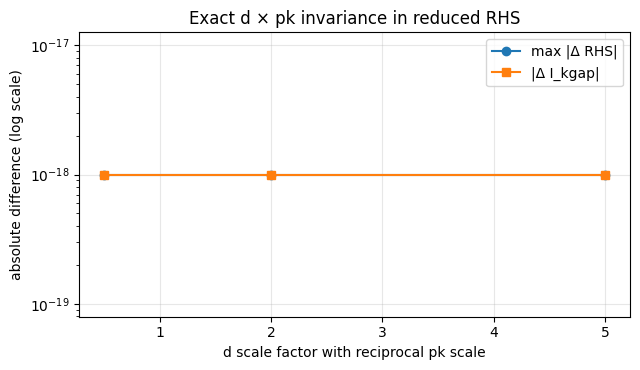

In [6]:
display(invariance[[
    "condition",
    "current_na",
    "scale_factor",
    "P_gap_eff_a",
    "P_gap_eff_b",
    "I_kgap_a",
    "I_kgap_b",
    "max_abs_rhs_delta",
    "structural_status",
    "claim_scope",
]])

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(invariance["scale_factor"], invariance["max_abs_rhs_delta"].clip(lower=1e-18), marker="o", label="max |Δ RHS|")
ax.semilogy(invariance["scale_factor"], (invariance["I_kgap_a"] - invariance["I_kgap_b"]).abs().clip(lower=1e-18), marker="s", label="|Δ I_kgap|")
ax.set_xlabel("d scale factor with reciprocal pk scale")
ax.set_ylabel("absolute difference (log scale)")
ax.set_title("Exact d × pk invariance in reduced RHS")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 8. Profile-loss / practical identifiability diagnostics

Terminology guardrail: this is a **profile-loss screen** / **profile-style practical identifiability diagnostic**. It fixes one coordinate at a time and applies an affine Vm nuisance calibration. It is not a definitive profile likelihood because it does not fully re-optimize all nuisance parameters at each fixed value.

,parameter_space,profile_parameter,base_value,min_profile_loss,max_delta_profile_loss,profile_classification,nuisance_refit_method,claim_guardrail
0,effective,P_gap_eff,0.000008,7.916000e-31,0.221281,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
1,effective,gamma_s_eff,0.000069,7.916000e-31,0.000000,flat_unbounded,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
2,effective,gamma_t_eff,0.000008,7.916000e-31,0.604958,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
3,effective,volume_ratio_wa_wo,1.527016,7.916000e-31,0.287920,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
4,raw,d,0.022632,7.916000e-31,0.221281,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
5,raw,gs,8.280126,7.916000e-31,0.000000,flat_unbounded,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
6,raw,gt,1.002385,7.916000e-31,0.604958,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
7,raw,pk,0.000340,7.916000e-31,0.221281,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...
8,raw,wo,1309.744213,7.916000e-31,0.287920,broad_valley,least_squares_affine_vm_scale_offset_not_full_...,limited identifiability/sloppiness under Vm-on...


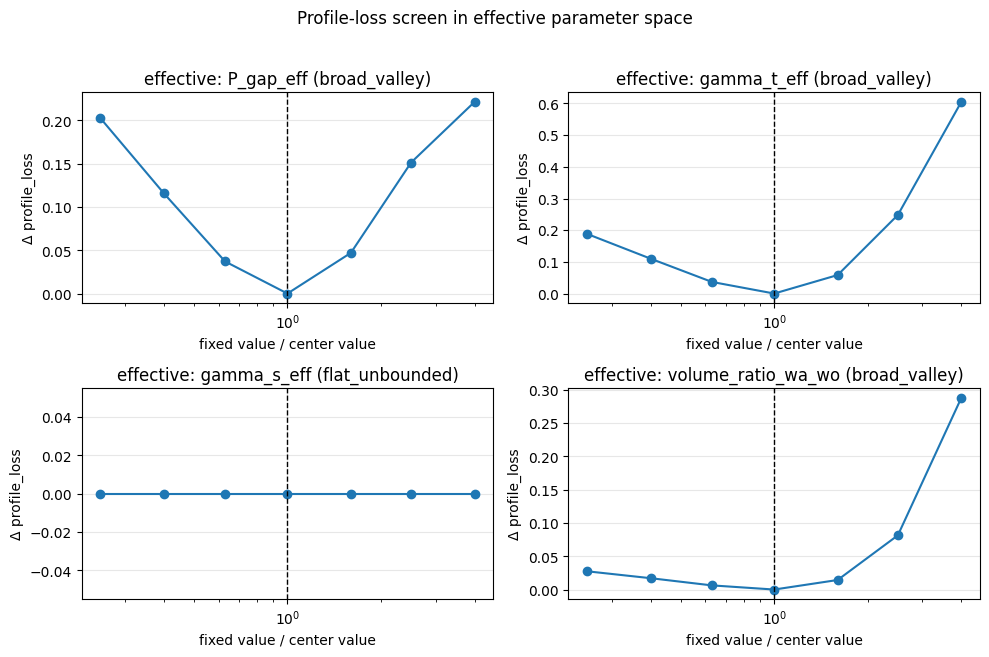

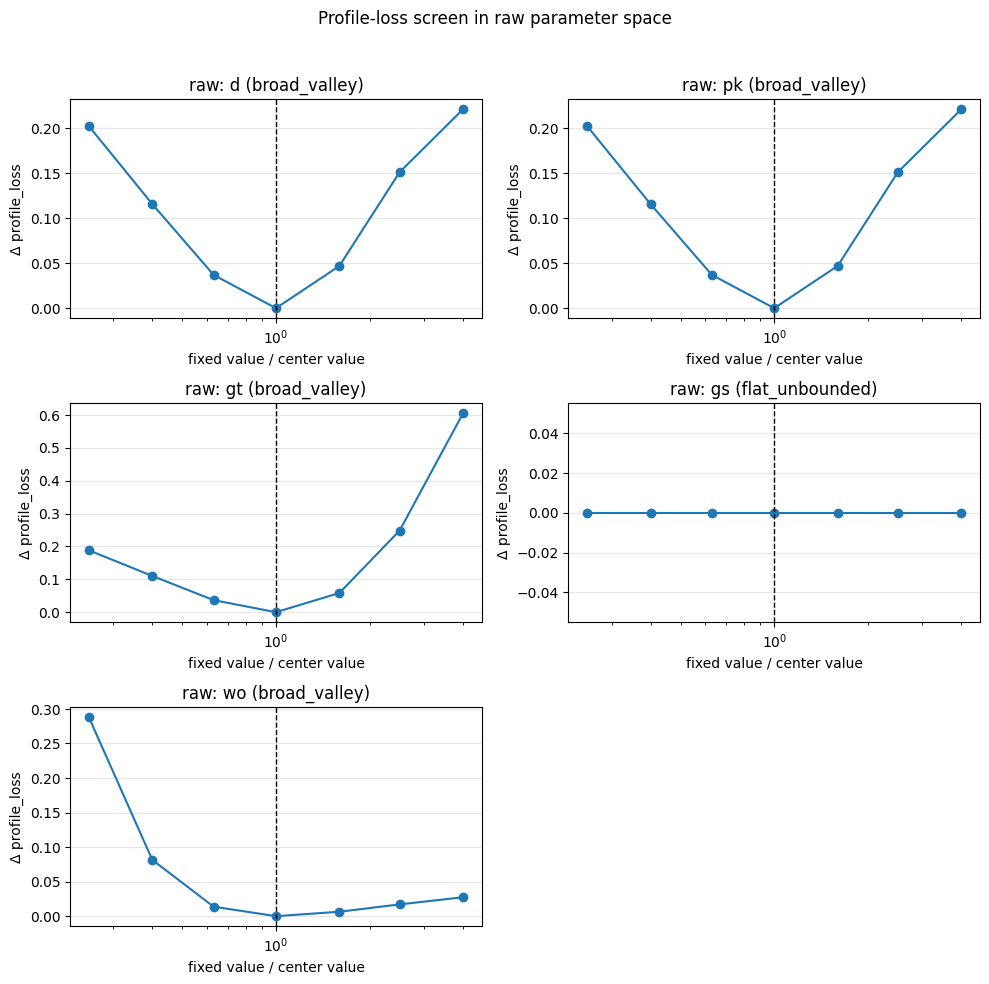

In [7]:
display(profile_summary[[
    "parameter_space",
    "profile_parameter",
    "base_value",
    "min_profile_loss",
    "max_delta_profile_loss",
    "profile_classification",
    "nuisance_refit_method",
    "claim_guardrail",
]])

for space, subspace in profiles.groupby("parameter_space"):
    params = list(subspace["profile_parameter"].drop_duplicates())
    ncols = 2
    nrows = (len(params) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.2 * nrows), squeeze=False)
    for ax, parameter in zip(axes.ravel(), params):
        sub = subspace[subspace["profile_parameter"] == parameter].sort_values("multiplier")
        ax.plot(sub["multiplier"], sub["delta_profile_loss"], marker="o")
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_title(f"{space}: {parameter} ({sub['profile_classification'].iloc[0]})")
        ax.set_xlabel("fixed value / center value")
        ax.set_ylabel("Δ profile_loss")
        ax.grid(True, alpha=0.3)
    for ax in axes.ravel()[len(params):]:
        ax.axis("off")
    fig.suptitle(f"Profile-loss screen in {space} parameter space", y=1.02)
    fig.tight_layout()
    plt.show()

## 9. FIM diagnostics and eigenspectra

Raw-space near-zero modes should be interpreted as raw-parameter non-identifiability/sloppiness. Effective-space modes are the primary scientific interpretation coordinates. Both remain local diagnostics around representative centers.

,condition,current_na,parameter_space,fim_is_symmetric,smallest_eigenvalue,largest_eigenvalue,near_zero_mode_count,log10_eigenvalue_span,claim_guardrail
0,CONTROL,75,effective,True,1.005389e-09,8945.382893,2,12.949265,limited identifiability/sloppiness under Vm-on...
1,CONTROL,75,raw,True,9.093672e-10,8967.926039,3,12.993953,limited identifiability/sloppiness under Vm-on...
2,MFA,100,effective,True,1.063936e-08,10273.544399,1,11.984805,limited identifiability/sloppiness under Vm-on...
3,MFA,100,raw,True,3.962642e-09,10342.615300,2,12.416646,limited identifiability/sloppiness under Vm-on...
4,BARIUM,100,effective,True,2.886528e-10,2367.288020,3,12.913875,limited identifiability/sloppiness under Vm-on...
5,BARIUM,100,raw,True,2.635981e-10,2372.745856,4,12.954309,limited identifiability/sloppiness under Vm-on...


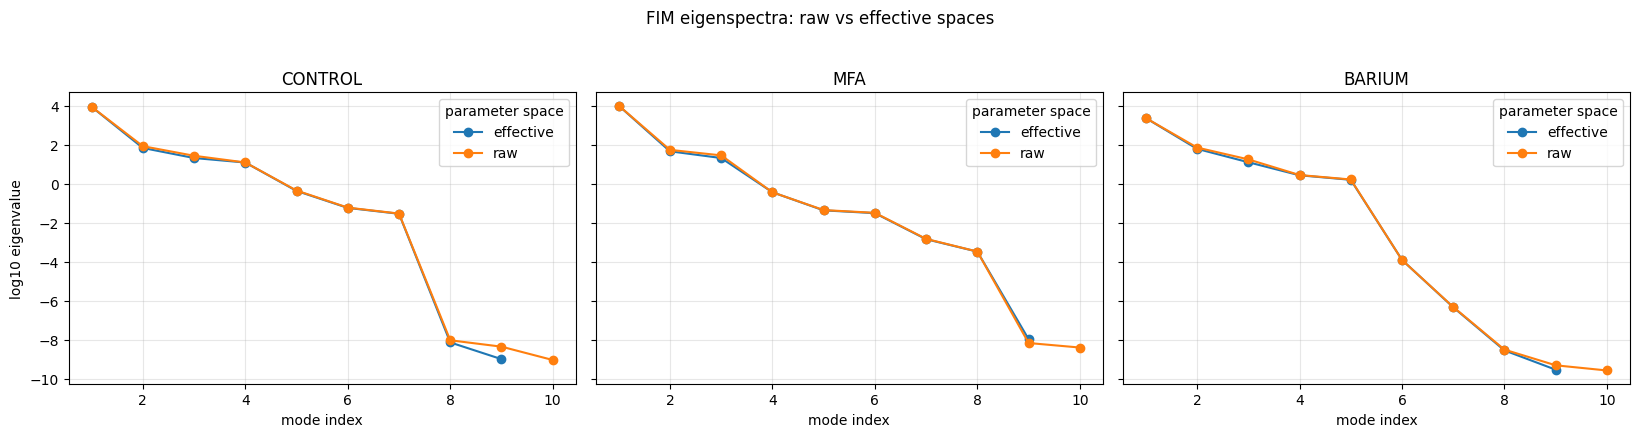

In [8]:
display(fim_diagnostics[[
    "condition",
    "current_na",
    "parameter_space",
    "fim_is_symmetric",
    "smallest_eigenvalue",
    "largest_eigenvalue",
    "near_zero_mode_count",
    "log10_eigenvalue_span",
    "claim_guardrail",
]])

conditions = list(fim_spectrum["condition"].drop_duplicates())
fig, axes = plt.subplots(1, len(conditions), figsize=(5.5 * len(conditions), 4.2), sharey=True)
if len(conditions) == 1:
    axes = [axes]
for ax, condition in zip(axes, conditions):
    csub = fim_spectrum[fim_spectrum["condition"] == condition]
    for space, sub in csub.groupby("parameter_space"):
        sub = sub.sort_values("mode_index")
        ax.plot(sub["mode_index"], sub["log10_eigenvalue"], marker="o", label=space)
    ax.set_title(condition)
    ax.set_xlabel("mode index")
    ax.grid(True, alpha=0.3)
    ax.legend(title="parameter space")
axes[0].set_ylabel("log10 eigenvalue")
fig.suptitle("FIM eigenspectra: raw vs effective spaces", y=1.03)
fig.tight_layout()
plt.show()

## 10. Dominant stiff/sloppy mode loadings

Dominant loadings identify local stiff/sloppy directions. They should guide identifiability interpretation, not mechanism or phenotype claims.

In [9]:
dominant_loadings = (
    fim_loadings.sort_values(["condition", "parameter_space", "mode_index", "abs_loading"], ascending=[True, True, True, False])
    .groupby(["condition", "current_na", "parameter_space", "mode_index"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)
display(dominant_loadings[[
    "condition",
    "current_na",
    "parameter_space",
    "mode_index",
    "parameter",
    "abs_loading",
    "mode_class",
    "coordinate_type",
    "claim_guardrail",
]].head(40))

,condition,current_na,parameter_space,mode_index,parameter,abs_loading,mode_class,coordinate_type,claim_guardrail
0,BARIUM,100,effective,1,K_bath_value_middle,0.994189,stiff,raw,limited identifiability/sloppiness under Vm-on...
1,BARIUM,100,effective,2,eps,0.630222,stiff,raw,limited identifiability/sloppiness under Vm-on...
2,BARIUM,100,effective,3,P_gap_eff,0.693794,stiff,effective,limited identifiability/sloppiness under Vm-on...
3,BARIUM,100,effective,4,gamma_t_eff,0.853033,stiff,effective,limited identifiability/sloppiness under Vm-on...
4,BARIUM,100,effective,5,gki,0.805835,sloppy,raw,limited identifiability/sloppiness under Vm-on...
5,BARIUM,100,effective,6,volume_ratio_wa_wo,0.714223,sloppy,effective,limited identifiability/sloppiness under Vm-on...
6,BARIUM,100,effective,7,ca,0.860193,sloppy,raw,limited identifiability/sloppiness under Vm-on...
7,BARIUM,100,effective,8,ca,0.508628,sloppy,raw,limited identifiability/sloppiness under Vm-on...
8,BARIUM,100,effective,9,gamma_s_eff,0.999992,sloppy,effective,limited identifiability/sloppiness under Vm-on...
9,BARIUM,100,raw,1,K_bath_value_middle,0.993046,stiff,raw,limited identifiability/sloppiness under Vm-on...


## 11. Observable design benchmark

This benchmark documents numerical/provenance sensitivity of the local FIM diagnostic to sparse versus dense observable designs. It does not address empirical variability/noise; that belongs to the threshold-weighted screening notebook.

,observable_design,condition,current_na,n_timepoints,observable_stride,n_observables,elapsed_seconds,n_modes,near_zero_mode_count,log10_eigenvalue_span,claim_guardrail
0,sparse,CONTROL,75,90,4,23,1.923469,9,2,12.947404,observable-design sensitivity only; not empiri...
1,dense,CONTROL,75,180,2,90,2.027719,9,2,12.949265,observable-design sensitivity only; not empiri...


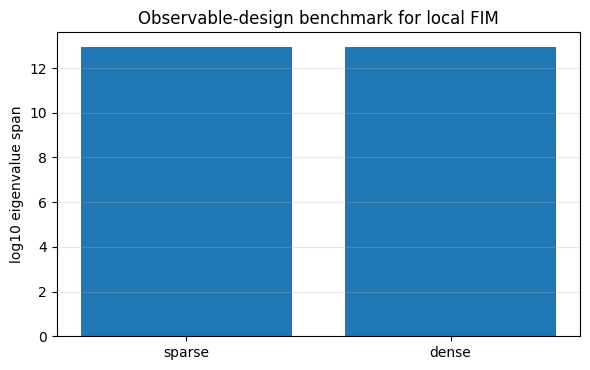

In [10]:
display(observable_benchmark)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(observable_benchmark["observable_design"], observable_benchmark["log10_eigenvalue_span"])
ax.set_ylabel("log10 eigenvalue span")
ax.set_title("Observable-design benchmark for local FIM")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 12. Reviewer-facing interpretation notes

In [11]:
display(interpretation_notes)
display(reviewer_response)

,diagnostic,finding,supports_claim,does_not_support_claim,reviewer_critique_targeted,manuscript_use
0,effective_parameter_map,Several raw coordinates enter the reduced Vm-o...,raw parameter estimates should not be overinte...,does not prove biological degeneracy,"R1,R4,R7",Supplementary table defining effective reporti...
1,d_pk_invariance,Reciprocal scaling of d and pk preserves P_gap...,d and pk are structurally non-separable in thi...,does not establish a complete STRIKE-GOLDD pro...,"R1,R4",Direct reviewer-response example showing why P...
2,profile_loss_screen,Profile-style perturbation curves classify loc...,some coordinates are only weakly constrained u...,does not prove biological degeneracy because n...,"R1,R4",Supplemental practical-identifiability diagnos...
3,fim_spectrum,Finite-difference FIM spectra show stiff and s...,sloppy directions exist and should be separate...,does not validate mechanism modes or predictiv...,"R1,R4,R7",Supplemental eigenspectrum figure and mode-loa...
4,raw_vs_effective_fim,Raw-space and effective-space FIMs are compare...,effective-space modes are the primary scientif...,does not make all effective coordinates biolog...,"R1,R4",Guardrail text explaining why raw-space near-z...
5,observable_design_benchmark,Sparse and dense observable designs are benchm...,diagnostic settings are explicit and auditable,does not address empirical variability/noise o...,R7,Methods/provenance note for supplementary diag...


,critique_targeted,diagnostic,output_file,conclusion,limitation
0,R1,d × pk invariance,invariance_diagnostics.csv,d/pk non-separable,not full STRIKE-GOLDD
1,R1,FIM spectrum,fim_spectrum.csv,sloppy directions exist,local only
2,R4,effective parameter map,effective_parameter_map.csv,report effective parameters,physiological interpretation still needs prior...
3,R7,interpretation notes,interpretation_notes.csv,clearer supplement,not a mechanistic result


## 13. Links to next-stage notebooks

### Link to empirical screening stage

The separate notebook `03_threshold_weighted_empirical_screening.ipynb` should be used as Step 03B / 04 to define accepted fits using empirical condition × region × sweep thresholds and reliability-weighted feature contracts.
This identifiability notebook provides parameter-interpretation guardrails; the threshold-screening notebook defines which candidate fits are accepted under experimental uncertainty.

Downstream analyses must handle:

- R2 empirical variability/noise through threshold-weighted accepted-fit screening;
- R3 model assumption sensitivity in model-family/proxy notebooks;
- R5 biological mechanism modes through accepted-ensemble Kir/gap/leak decomposition;
- R6 predictive robustness through held-out current or perturbation validation.

## 14. Output assertions / smoke tests

In [12]:
claim_boundary_text = """
This notebook is not a biological degeneracy result. It is an identifiability screen showing raw/effective parameter limits and local sloppiness under Vm-only observation.
"""

assert (OUTPUT_DIR / "effective_parameter_map.csv").exists()
assert (OUTPUT_DIR / "invariance_diagnostics.csv").exists()
assert (OUTPUT_DIR / "profile_likelihoods.csv").exists() or (OUTPUT_DIR / "profile_loss_screen.csv").exists()
assert (OUTPUT_DIR / "fim_spectrum.csv").exists()
assert (OUTPUT_DIR / "fim_mode_loadings.csv").exists()
assert (OUTPUT_DIR / "fim_diagnostics.csv").exists()
assert (OUTPUT_DIR / "interpretation_notes.csv").exists()
assert (OUTPUT_DIR / "analysis_summary.json").exists()
assert (OUTPUT_DIR / "notebook_config.json").exists()
assert "not" in claim_boundary_text.lower() and "biological degeneracy" in claim_boundary_text.lower()

with open(OUTPUT_DIR / "analysis_summary.json", "r", encoding="utf-8") as f:
    machine_summary = json.load(f)
required_keys = {
    "notebook_name",
    "step_name",
    "claim_scope",
    "critiques_targeted",
    "critiques_not_resolved",
    "representative_centers",
    "n_profile_diagnostics",
    "n_fim_modes",
    "uses_raw_space_fim",
    "uses_effective_space_fim",
    "has_d_pk_invariance_check",
    "has_interpretation_notes",
    "next_required_steps",
}
assert required_keys.issubset(machine_summary)
assert machine_summary["uses_raw_space_fim"] is True
assert machine_summary["uses_effective_space_fim"] is True
assert machine_summary["has_d_pk_invariance_check"] is True
assert machine_summary["has_interpretation_notes"] is True
machine_summary

{'notebook_name': '03_combined_identifiability_profiles_fim.ipynb',
 'step_name': 'Step 03A identifiability/effective-parameter/FIM screen',
 'claim_scope': 'identifiability_screen_not_biological_degeneracy',
 'critiques_targeted': ['R1', 'R4', 'partial R7'],
 'critiques_not_resolved': ['R2 empirical variability/noise',
  'R3 model assumption sensitivity',
  'R5 biological mechanism modes',
  'R6 predictive robustness/CV'],
 'representative_centers': [{'db_name': 'CONTROL_75nA.db',
   'condition': 'CONTROL',
   'current_na': 75,
   'trial_number': 2425},
  {'db_name': 'MFA_100nA.db',
   'condition': 'MFA',
   'current_na': 100,
   'trial_number': 0},
  {'db_name': 'BARIUM_100nA.db',
   'condition': 'BARIUM',
   'current_na': 100,
   'trial_number': 0}],
 'n_profile_diagnostics': 9,
 'n_fim_modes': 57,
 'uses_raw_space_fim': True,
 'uses_effective_space_fim': True,
 'has_d_pk_invariance_check': True,
 'has_interpretation_notes': True,
 'next_required_steps': ['Step 03B/04 threshold-weig

## Final reviewer-facing conclusion

This notebook supports R1/R4 by showing raw/effective identifiability limits and local sloppiness. It does not claim biological degeneracy. The degeneracy claim must be evaluated downstream using accepted ensembles, mechanism decomposition, and predictive validation.